Create a new notebook in your working directory. Copy these instructions as plain text into the first cell. That way you will not have to flip back and forth between your notebook and this page.
Make sure that the astropy and sep packages are installed on your machine by launching a command window and running:
pip install astropy
pip install sep
Download the file hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits from this archiveLinks to an external site. and save it to your working directory (the same directory that has your notebook).

In [1]:
import sys
!{sys.executable} -m pip install sep astropy

In [2]:
import numpy as np
import sep
import matplotlib.pyplot as plt

In [3]:
from matplotlib import rcParams
from astropy.io import fits

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [4]:
hdul = fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")
data = hdul[0].data

data = data.byteswap().view(data.dtype.newbyteorder('='))

data = data.astype(np.float32)

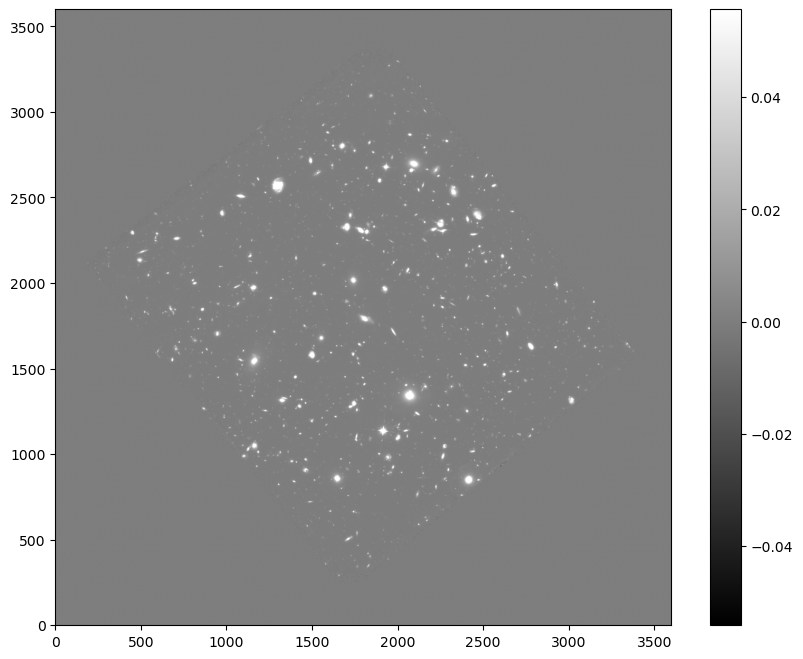

In [5]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()

In [6]:
bkg = sep.Background(data, bw=128, bh=128, fw=3, fh=3)

print(bkg.globalback)
print(bkg.globalrms)

data_sub = data - bkg

0.0
0.0005450149765238166


In [7]:
objects = sep.extract(data_sub, 3.0, err=bkg.globalrms)

print("Amount of space objects detected:", len(objects))

Amount of space objects detected: 4315


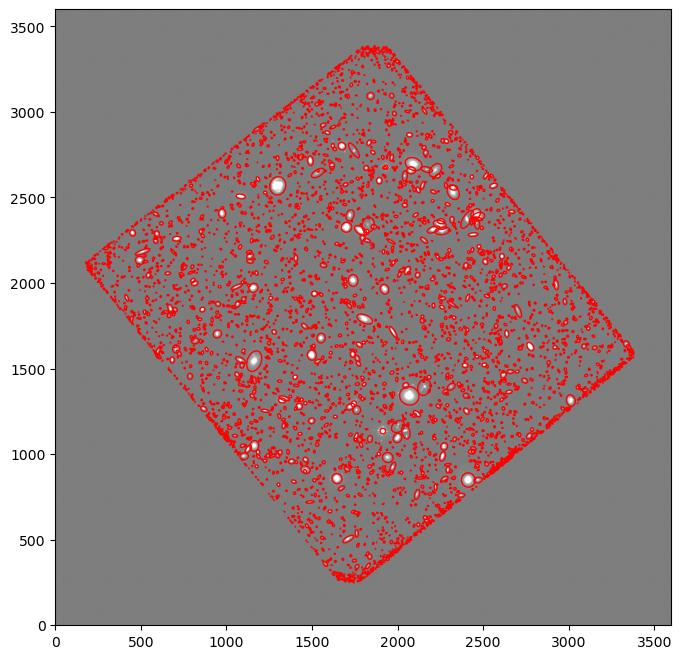

In [8]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)

ax.imshow(data_sub, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')

for i in range(len(objects)):
    e = Ellipse(
        xy=(objects['x'][i], objects['y'][i]),
        width=6*objects['a'][i],
        height=6*objects['b'][i],
        angle=objects['theta'][i] * 180. / np.pi
    )
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [9]:
flux, fluxerr, flag = sep.sum_circle(
    data_sub,
    objects['x'],
    objects['y'],
    3.0,
    err=bkg.globalrms,
    gain=1.0
)

Number of sources: 4315


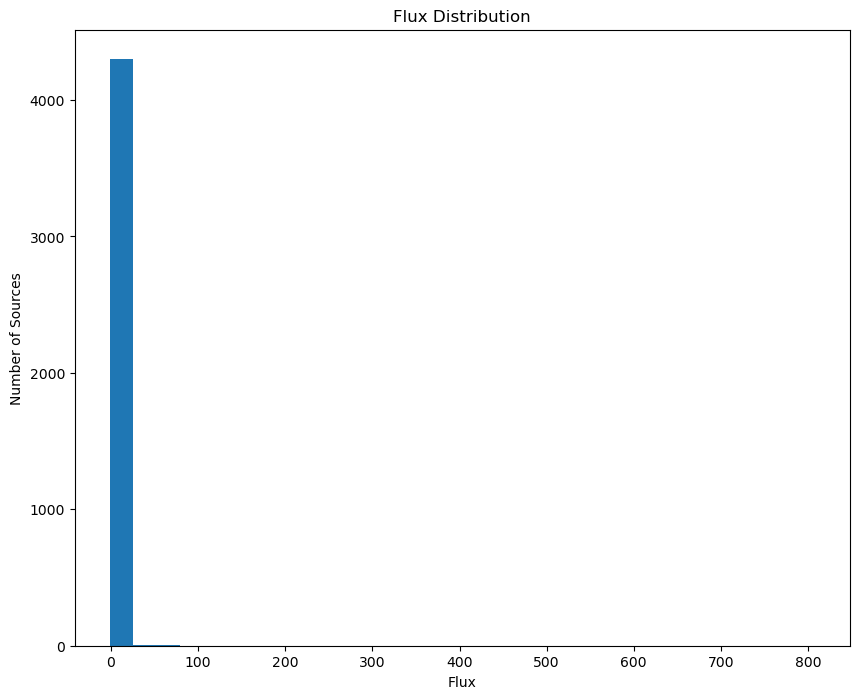

Mean: 0.7078693059954477
Median: 0.0741911768980208
Standard Deviation: 13.075440786025124
Largest flux: 807.4907817077637
Standard deviations from mean: 61.70215793138295


In [10]:
##question 1
print("Number of sources:", len(flux))

plt.hist(flux, bins=30)
plt.xlabel("Flux")
plt.ylabel("Number of Sources")
plt.title("Flux Distribution")
plt.show()

##question 2
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean:", mean_flux)
print("Median:", median_flux)
print("Standard Deviation:", std_flux)

##question 3
max_flux = np.max(flux)

z_score = (max_flux - mean_flux) / std_flux

print("Largest flux:", max_flux)
print("Standard deviations from mean:", z_score)